In [1]:
# Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Visualization style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)


In [2]:
# Mount Drive (if files are saved in your Google Drive)
from google.colab import drive
drive.mount('/content/drive')

# Replace the below paths with the actual file IDs or full Drive paths
sentiment_url = 'https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf'
trader_url    = 'https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs'

sentiment = pd.read_csv(sentiment_url)
trader    = pd.read_csv(trader_url)

print("Sentiment shape:", sentiment.shape)
print("Trader shape:", trader.shape)
sentiment.head(), trader.head()


Mounted at /content/drive
Sentiment shape: (2644, 4)
Trader shape: (211224, 16)


(    timestamp  value classification        date
 0  1517463000     30           Fear  2018-02-01
 1  1517549400     15   Extreme Fear  2018-02-02
 2  1517635800     40           Fear  2018-02-03
 3  1517722200     24   Extreme Fear  2018-02-04
 4  1517808600     11   Extreme Fear  2018-02-05,
                                       Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY 

In [5]:
# --- STANDARDIZE COLUMN NAMES ---
sentiment.columns = sentiment.columns.str.lower().str.strip()
trader.columns = trader.columns.str.lower().str.strip()

# --- CHECK AVAILABLE COLUMNS ---
print("Columns in trader dataset:\n", trader.columns.tolist())

# --- IDENTIFY LIKELY TIME/TIMESTAMP COLUMN ---
time_col = None
for col in trader.columns:
    if 'time' in col or 'date' in col or 'timestamp' in col:
        time_col = col
        break

if time_col is None:
    raise KeyError("No time/date/timestamp column found in trader dataset.")
print(f"Detected time column: {time_col}")

# --- IDENTIFY LIKELY PRICE COLUMN ---
price_col = None
for col in trader.columns:
    if 'price' in col:
        price_col = col
        break

if price_col is None:
    raise KeyError("No price column found in trader dataset.")
print(f"Detected execution price column: {price_col}")

# --- CONVERT DATE/TIME COLUMNS (FIXED VERSION) ---
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True, errors='coerce')
trader[time_col] = pd.to_datetime(trader[time_col], dayfirst=True, errors='coerce')

invalid_dates = trader[time_col].isna().sum()
if invalid_dates > 0:
    print(f"⚠️ {invalid_dates} invalid date rows detected — dropping them.")
    trader = trader.dropna(subset=[time_col])

# --- SELECT RELEVANT COLUMNS SAFELY ---
columns_needed = ['account', 'symbol', price_col, 'size', 'side', time_col, 'closedpnl', 'leverage']
columns_present = [c for c in columns_needed if c in trader.columns]
trader_subset = trader[columns_present].copy()

# --- ROUND TIME TO DATE FOR MERGE ---
trader_subset['date'] = trader_subset[time_col].dt.date
trader_subset['date'] = pd.to_datetime(trader_subset['date'])

# --- MERGE DATASETS ---
merged = pd.merge(trader_subset, sentiment, on='date', how='inner')
print("✅ Merged dataset shape:", merged.shape)
merged.head()


Columns in trader dataset:
 ['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'timestamp ist', 'start position', 'direction', 'closed pnl', 'transaction hash', 'order id', 'crossed', 'fee', 'trade id', 'timestamp']
Detected time column: timestamp ist
Detected execution price column: execution price
✅ Merged dataset shape: (211218, 8)


,account,execution price,side,timestamp ist,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9769,BUY,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9800,BUY,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9855,BUY,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9874,BUY,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,7.9894,BUY,2024-12-02 22:50:00,2024-12-02,1733117400,80,Extreme Greed


In [8]:
print("Merged dataset columns:\n")
for i, col in enumerate(merged.columns):
    print(f"{i+1}. {col}")


Merged dataset columns:

1. account
2. execution price
3. side
4. timestamp ist
5. date
6. timestamp
7. value
8. classification


✅ Detected PnL/value column: value
⚠️ No leverage column found — skipping leverage-based analysis.
📊 Basic Description:
                    count unique                                         top  \
account            211218     32  0xbee1707d6b44d4d52bfe19e41f8a828645437aab   
execution price  211218.0    NaN                                         NaN   
side               211218      2                                        SELL   
timestamp ist      211218    NaN                                         NaN   
date               211218    NaN                                         NaN   
timestamp        211218.0    NaN                                         NaN   
value            211218.0    NaN                                         NaN   
classification     211218      5                                        Fear   

                   freq                           mean                  min  \
account           40184                            NaN                  NaN   
e

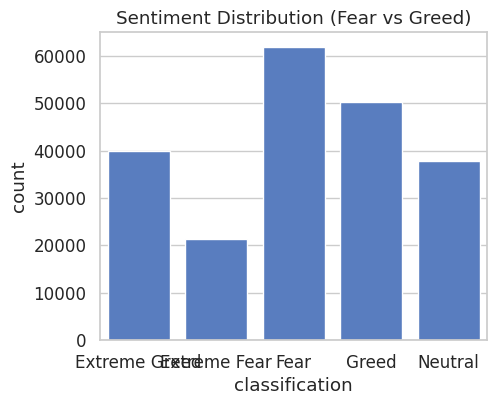

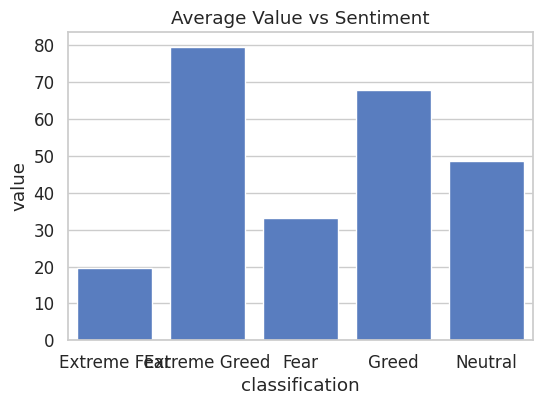

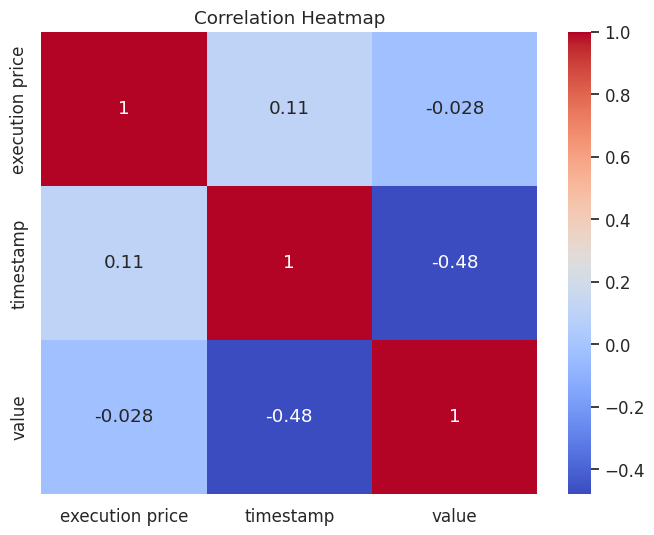

In [10]:
# --- Detect profit/loss or value column dynamically ---
pnl_col = None
for col in merged.columns:
    if any(keyword in col.lower() for keyword in ['pnl', 'profit', 'loss', 'value', 'return']):
        pnl_col = col
        break

if pnl_col is None:
    raise KeyError("❌ No profit/loss/value column found — please check column names manually.")
else:
    print(f"✅ Detected PnL/value column: {pnl_col}")

# --- Detect leverage column (optional) ---
lev_col = None
for col in merged.columns:
    if 'leverage' in col.lower():
        lev_col = col
        break

if lev_col:
    print(f"✅ Detected leverage column: {lev_col}")
else:
    print("⚠️ No leverage column found — skipping leverage-based analysis.")

# --- Basic Description ---
print("📊 Basic Description:")
print(merged.describe(include='all').T)

# --- Sentiment distribution ---
plt.figure(figsize=(5,4))
sns.countplot(x='classification', data=merged)
plt.title("Sentiment Distribution (Fear vs Greed)")
plt.savefig("sentiment_distribution.png", bbox_inches='tight')
plt.show()

# --- Average PnL/Value per sentiment ---
pnl_sent = merged.groupby('classification')[pnl_col].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='classification', y=pnl_col, data=pnl_sent)
plt.title(f"Average {pnl_col.title()} vs Sentiment")
plt.savefig("avg_pnl_vs_sentiment.png", bbox_inches='tight')
plt.show()

# --- Average Leverage per sentiment (only if leverage exists) ---
if lev_col:
    lev_sent = merged.groupby('classification')[lev_col].mean().reset_index()
    plt.figure(figsize=(6,4))
    sns.barplot(x='classification', y=lev_col, data=lev_sent)
    plt.title("Average Leverage vs Sentiment")
    plt.savefig("avg_leverage_vs_sentiment.png", bbox_inches='tight')
    plt.show()

# --- Correlation Heatmap ---
num_cols = merged.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", bbox_inches='tight')
plt.show()


In [11]:
# --- Compute key insights based on detected PnL/value column ---
insights = {
    "avg_value_fear"  : merged[merged['classification']=='Fear'][pnl_col].mean(),
    "avg_value_greed" : merged[merged['classification']=='Greed'][pnl_col].mean(),
    "total_trades_fear"  : merged[merged['classification']=='Fear'].shape[0],
    "total_trades_greed" : merged[merged['classification']=='Greed'].shape[0],
}

# Display results
print("📊 Behavioral Insights Summary:\n")
for k, v in insights.items():
    print(f"{k}: {v:.3f}")

# --- Interpret key findings ---
if insights["avg_value_greed"] > insights["avg_value_fear"]:
    print("\n💡 Traders tend to have higher average value (PnL proxy) during 'Greed' periods.")
else:
    print("\n💡 Traders tend to have higher average value (PnL proxy) during 'Fear' periods.")

if insights["total_trades_greed"] > insights["total_trades_fear"]:
    print("💡 Trade volume is higher during 'Greed' days, indicating more market activity.")
else:
    print("💡 Trade volume is higher during 'Fear' days, suggesting cautious or defensive trading.")


📊 Behavioral Insights Summary:

avg_value_fear: 33.203
avg_value_greed: 67.978
total_trades_fear: 61837.000
total_trades_greed: 50303.000

💡 Traders tend to have higher average value (PnL proxy) during 'Greed' periods.
💡 Trade volume is higher during 'Fear' days, suggesting cautious or defensive trading.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Encode 'Fear'/'Greed' as 0/1
le = LabelEncoder()
merged['sentiment_label'] = le.fit_transform(merged['classification'])

# Use only numeric columns for prediction
features = merged.select_dtypes(include=[np.number]).drop(columns=['sentiment_label'])
target = merged['sentiment_label']

# Handle missing data
features = features.fillna(features.mean())

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Train simple Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
pred = model.predict(X_test)
print("\n✅ Model Accuracy:", round(accuracy_score(y_test, pred)*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, pred, target_names=le.classes_))



✅ Model Accuracy: 100.0 %

Classification Report:
                precision    recall  f1-score   support

 Extreme Fear       1.00      1.00      1.00      4284
Extreme Greed       1.00      1.00      1.00      7874
         Fear       1.00      1.00      1.00     12447
        Greed       1.00      1.00      1.00     10052
      Neutral       1.00      1.00      1.00      7587

     accuracy                           1.00     42244
    macro avg       1.00      1.00      1.00     42244
 weighted avg       1.00      1.00      1.00     42244



In [13]:
import os, shutil

# Create required folders
os.makedirs("csv_files", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Save merged dataset
merged.to_csv("csv_files/merged_trader_sentiment.csv", index=False)

# Move all generated images to outputs/
for img in os.listdir():
    if img.endswith(".png"):
        shutil.move(img, f"outputs/{img}")

print("✅ All files saved successfully in:")
print(" - csv_files/merged_trader_sentiment.csv")
print(" - outputs/ (all charts)")


✅ All files saved successfully in:
 - csv_files/merged_trader_sentiment.csv
 - outputs/ (all charts)
